<a href="https://colab.research.google.com/github/adytriaby/PCVK_Ganjil2026/blob/main/week2_PCDVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ktm.jpeg to ktm.jpeg


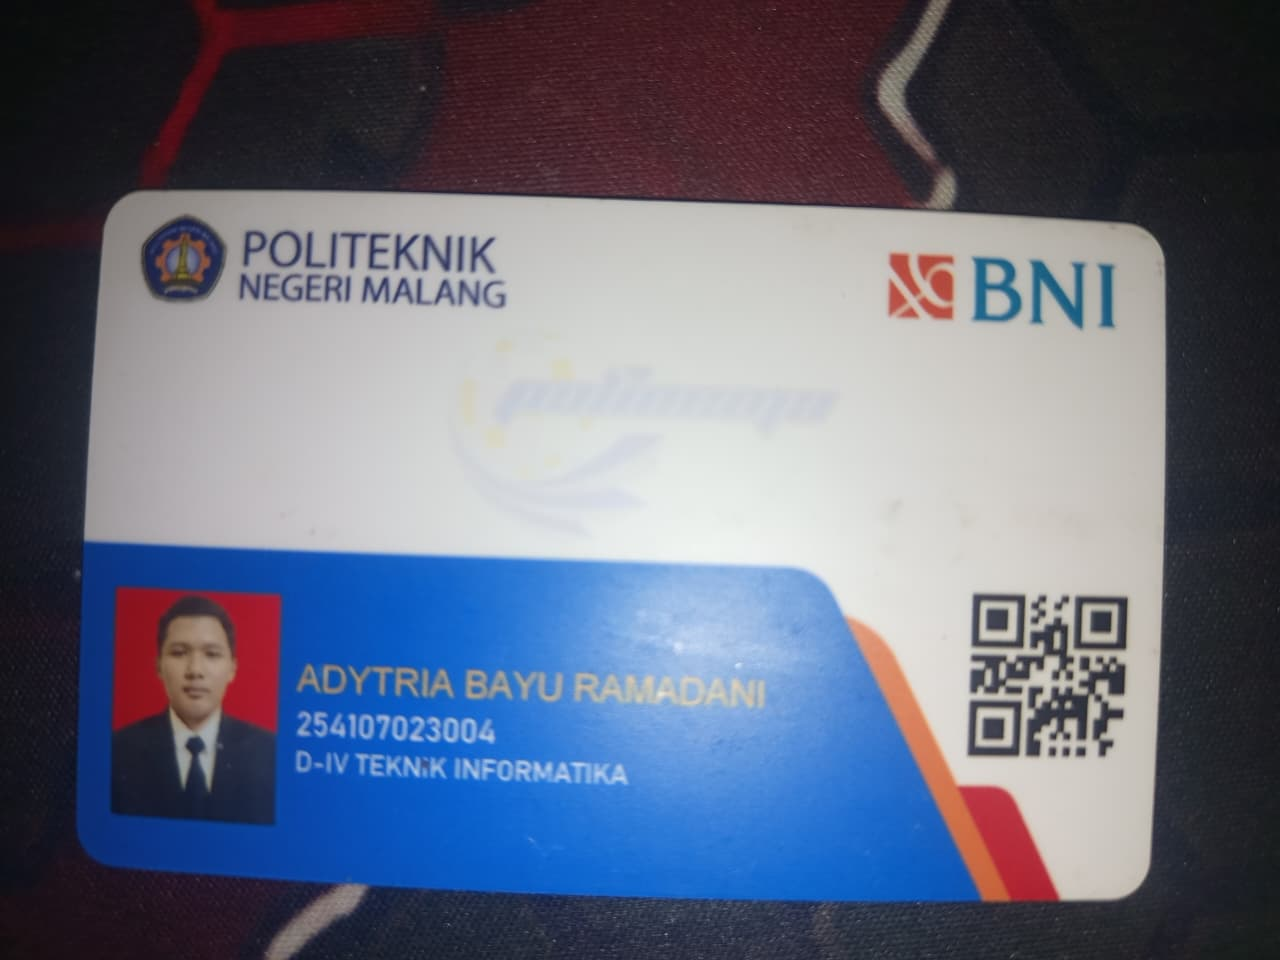

Resolusi gambar:  1280 x 960


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt

img = cv.imread('ktm.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

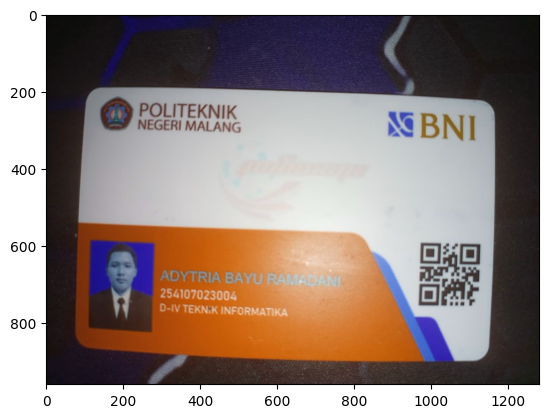

In [4]:
img = cv.imread('ktm.jpeg')
plt.imshow(img)

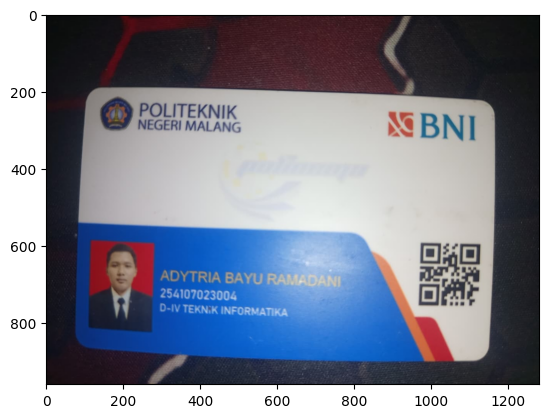

In [5]:
img = cv.imread('ktm.jpeg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)

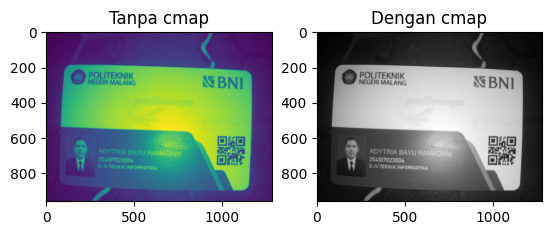

In [6]:
img_gray = cv.imread('ktm.jpeg', cv.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

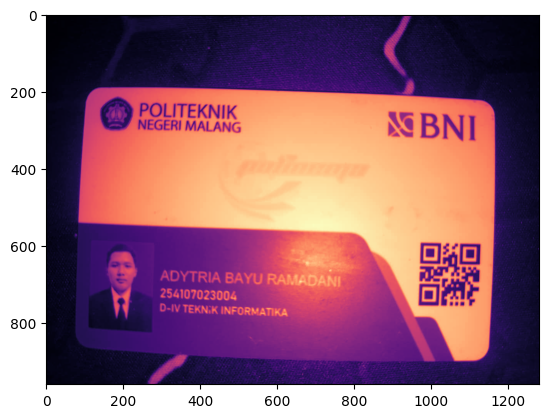

In [7]:
plt.imshow(img_gray, cmap='magma')

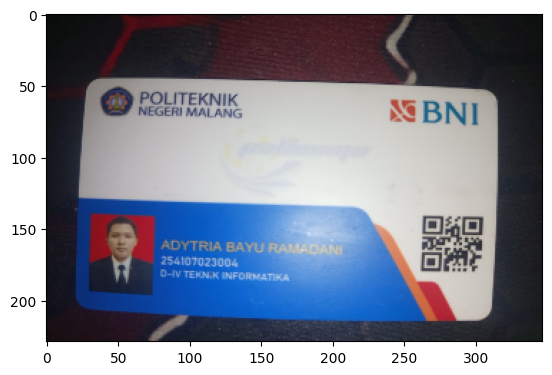

In [8]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

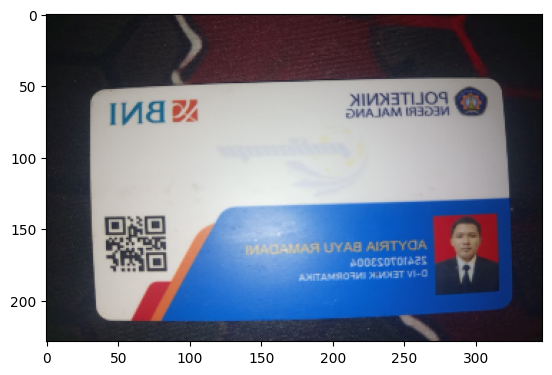

In [9]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

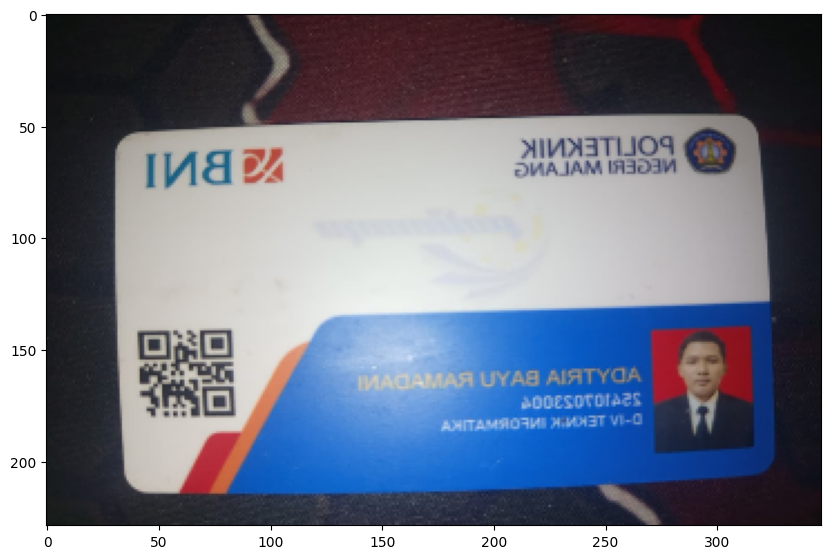

In [10]:
imgFlip=cv.flip(img_output, 1)

fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

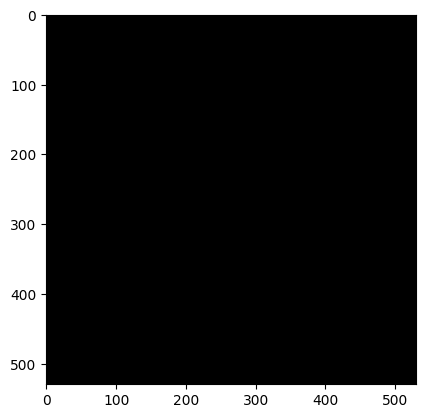

In [11]:
import numpy as np

black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)
plt.imshow(black_img)

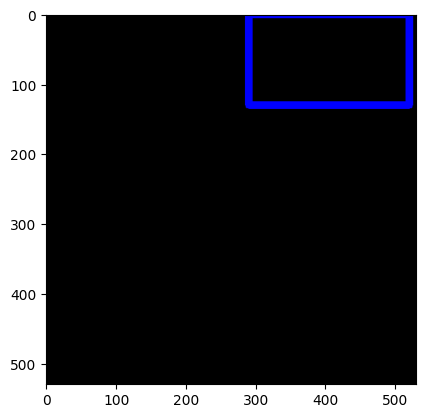

In [12]:
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0, 0, 255), thickness=10)
plt.imshow(black_img)

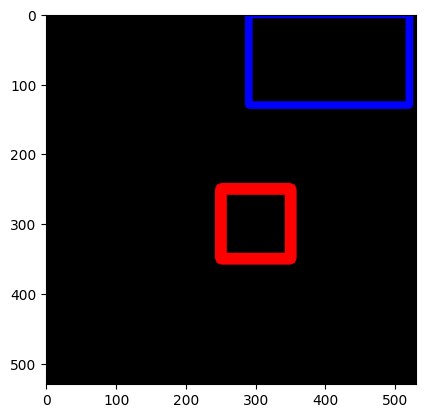

In [13]:
cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255, 0, 0), thickness=15)
plt.imshow(black_img)

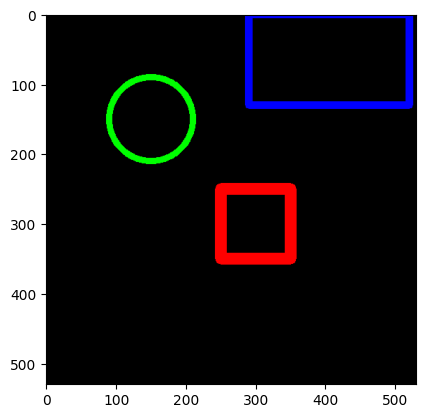

In [14]:
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness = 8)
plt.imshow(black_img)


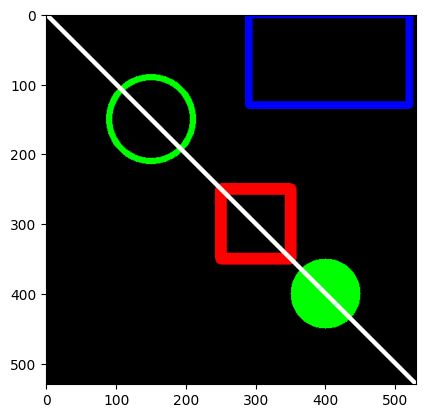

In [15]:
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

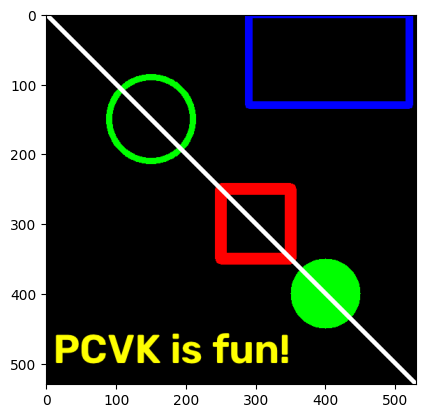

In [16]:
font = cv.FONT_HERSHEY_SIMPLEX
black_img = black_img.astype(np.uint8)
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2, color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

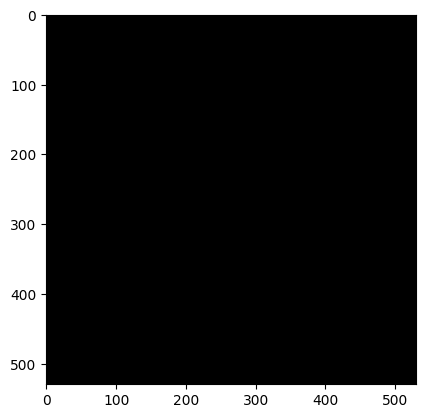

In [17]:
black_img2=np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [18]:
vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [19]:
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

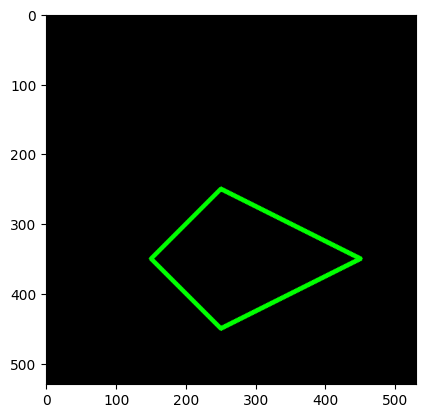

In [20]:
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

Nilai piksel cv2 (BGR) : [13 11 10]
Nilai piksel skimage (RGB): [10 11 13]


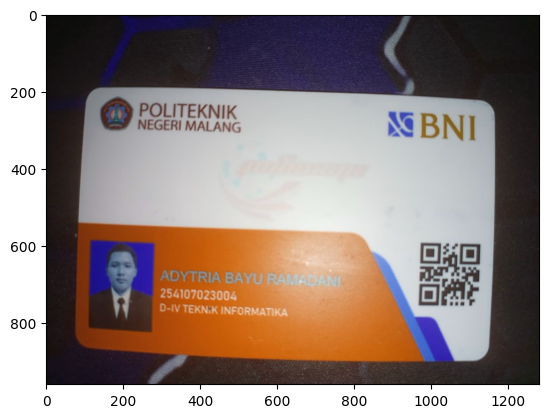

In [22]:
#PERTANYAAN PRAKTIKUM (1)
import cv2
import matplotlib.pyplot as plt
import skimage.io as io

img_cv2 = cv2.imread('ktm.jpeg') # Format BGR
img_plt = io.imread('ktm.jpeg')  # Format RGB

print("Nilai piksel cv2 (BGR) :", img_cv2[0, 0])
print("Nilai piksel skimage (RGB):", img_plt[0, 0])

plt.imshow(img_cv2)
#plt.imshow(img_plt)

int16 -> dtype: int16, min: 0, max: 0, nbytes: 20000 bytes
int32 -> dtype: int32, min: 0, max: 0, nbytes: 40000 bytes


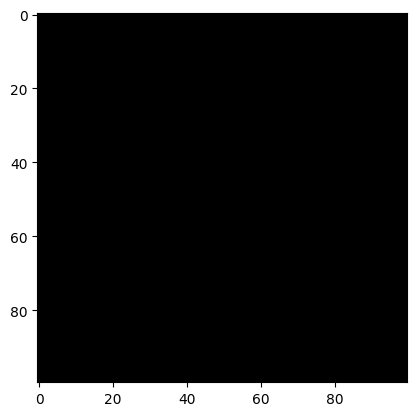

In [23]:
#PERTANYAAN PRAKTIKUM (2)

import numpy as np

kanvas_16 = np.zeros((100, 100), dtype=np.int16)
kanvas_32 = np.zeros((100, 100), dtype=np.int32)

print(f"int16 -> dtype: {kanvas_16.dtype}, min: {kanvas_16.min()}, max: {kanvas_16.max()}, nbytes: {kanvas_16.nbytes} bytes")
print(f"int32 -> dtype: {kanvas_32.dtype}, min: {kanvas_32.min()}, max: {kanvas_32.max()}, nbytes: {kanvas_32.nbytes} bytes")

black_img3=np.zeros((100, 100, 3), dtype=np.int16)
#black_img3=np.zeros((100, 100, 3), dtype=np.int32)
plt.imshow(black_img3)

Untuk tampilan keduanya sama-sama hitam pekat, tetapi pada ukuran berbeda karena kanvas int16 menggunakan 2 byte per piksel, sedangkan int32 menggunakan 4 byte per piksel.

PERTANYAAN PRAKTIKUM (3)

Fungsi cv2.imshow() bawaan OpenCV dirancang untuk membuka jendela GUI eksternal pada sistem operasi lokal. Karena Google Colab berjalan di browser pada server cloud, ia tidak dapat merender jendela GUI lokal. Oleh karena itu, patch cv2_imshow disediakan untuk merender matriks citra menjadi format gambar (seperti PNG) agar bisa ditampilkan sebaris (inline) di antarmuka Colab.

Piksel skimage.io       : [10 11 13]
Piksel cv2 + cvtColor   : [10 11 13]


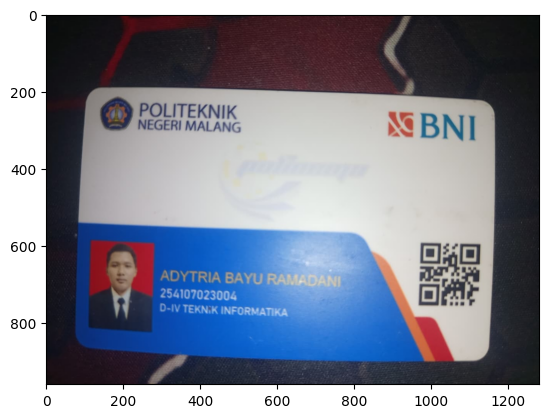

In [24]:
#PERTANYAAN PRAKTIKUM (4)

img_skimage = io.imread('ktm.jpeg')
img_cv2 = cv2.imread('ktm.jpeg')
img_converted = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

print("Piksel skimage.io       :", img_skimage[0, 0])
print("Piksel cv2 + cvtColor   :", img_converted[0, 0])

plt.imshow(img_converted)

Keduanya menampilkan warna yang sebenarnya jika sudah dikonversi. skimage.io.imread membaca RGB, sedangkan cv2.cvtColor mengonversi BGR hasil bacaan OpenCV menjadi RGB.

PERTANYAAN PRAKTIKUM (5)

Nilai img.shape tidak akan berubah, mengubah parameter figsize pada Matplotlib hanya memanipulasi ukuran tampilan (area kanvas/plot di layar visual), sedangkan matriks data citra aslinya (dimensi array NumPy) tetap sama di dalam memori.

In [25]:
#TUGAS PRAKTIKUM - PENERAPAN

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
#TUGAS PRAKTIKUM - PENERAPAN

from google.colab import files
uploaded = files.upload()

Saving lenna.jpg to lenna (1).jpg


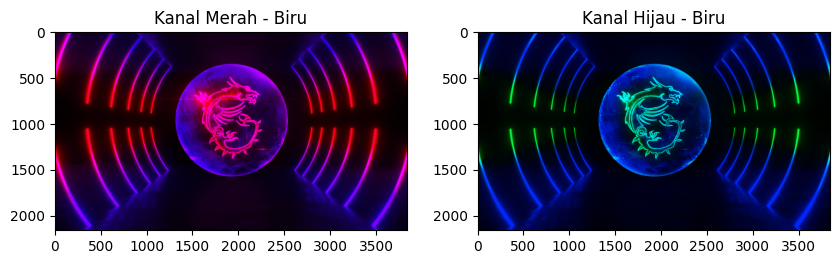

In [35]:
import cv2
import matplotlib.pyplot as plt

# 1. Buka gambar
img = cv2.imread('lenna (1).jpg')

# Cek apakah gambar berhasil dibaca
if img is None:
    print("Gambar tidak ditemukan! Cek kembali lokasi/nama file-nya.")
else:
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Merah-Biru (matikan kanal Hijau / index 1)
    img_rb = img_rgb.copy()
    img_rb[:, :, 1] = 0

    # Hijau-Biru (matikan kanal Merah / index 0)
    img_gb = img_rgb.copy()
    img_gb[:, :, 0] = 0

    # Tampilkan gambar
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_rb)
    axs[0].set_title('Kanal Merah - Biru')
    axs[1].imshow(img_gb)
    axs[1].set_title('Kanal Hijau - Biru')
    plt.show()

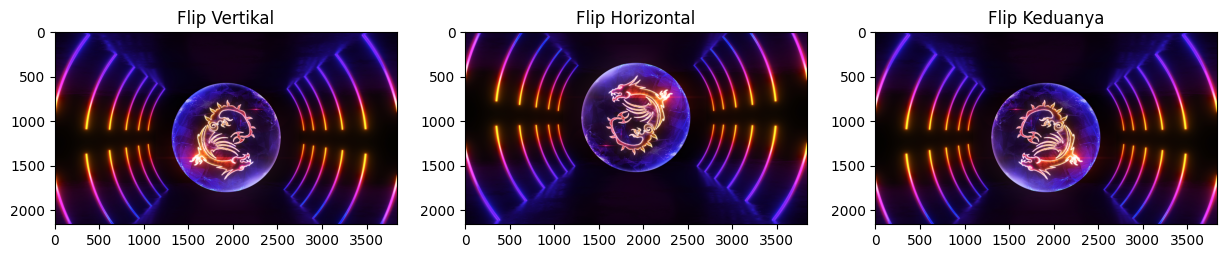

In [36]:
#TUGAS PRAKTIKUM - PENERAPAN

# 2. Pencerminan Citra
flip_v = cv2.flip(img_rgb, 0)
flip_h = cv2.flip(img_rgb, 1)
flip_both = cv2.flip(img_rgb, -1)

fig2, axs2 = plt.subplots(1, 3, figsize=(15, 5))
axs2[0].imshow(flip_v)
axs2[0].set_title('Flip Vertikal')
axs2[1].imshow(flip_h)
axs2[1].set_title('Flip Horizontal')
axs2[2].imshow(flip_both)
axs2[2].set_title('Flip Keduanya')
plt.show()

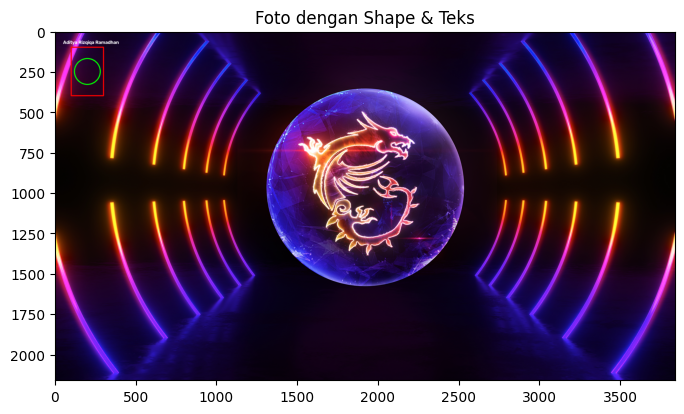

In [37]:

#TUGAS PRAKTIKUM - PENERAPAN

# 3. Menggambar Shape dan Teks Nama
img_draw = img_rgb.copy()

cv2.rectangle(img_draw, (100, 100), (300, 400), (255, 0, 0), 5)
cv2.circle(img_draw, (200, 250), 80, (0, 255, 0), 5)

# Menambahkan Teks Nama (Ukuran font adaptif)
cv2.putText(img_draw, 'Aditya Rizqiqa Ramadhan', (50, 80),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

plt.figure(figsize=(8, 6))
plt.imshow(img_draw)
plt.title('Foto dengan Shape & Teks')
plt.show()

In [38]:
#TUGAS PRAKTIKUM - ANALISA

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [39]:
#TUGAS PRAKTIKUM - ANALISA

from google.colab import files
uploaded = files.upload()

Saving ktm1.jpeg to ktm1.jpeg


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

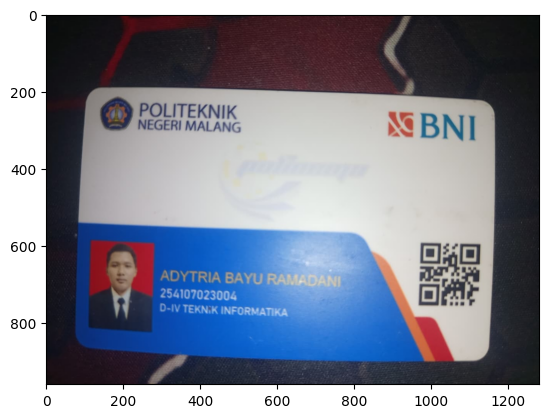

In [41]:
#TUGAS PRAKTIKUM - ANALISA

img = cv2.imread('ktm1.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt

In [42]:
#PRAKTIKUM - ANALISA

wajah = img_rgb[100:400, 100:300]
red_channel = wajah[:, :, 0]
red_pixels_high = np.sum(red_channel > 150)
total_pixels = wajah.shape[0] * wajah.shape[1]
persentase = (red_pixels_high / total_pixels) * 100
print(f"Persentase piksel merah > 150: {persentase:.2f}%")

Persentase piksel merah > 150: 40.31%


In [43]:
#TUGAS PRAKTIKUM - APLIKASI

import cv2
import numpy as np

In [44]:
from google.colab import files
uploaded = files.upload()

Saving 123.jpeg to 123.jpeg


In [50]:
from google.colab import files
uploaded = files.upload()

Saving 21.png to 21.png


In [61]:
def tambah_label_dokumentasi(image_path):
    # 1. Baca gambar ke variabel 'img'
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"File '{image_path}' tidak ditemukan!")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Hitung dimensi gambar
    h, w, _ = img_rgb.shape
    bar_height = h // 12

    # 3. Bar label hitam di bagian bawah gambar
    cv2.rectangle(img_rgb, (0, h - bar_height), (w, h), (0, 0, 0), -1)

    # 4. Hitung ukuran font adaptif
    font_scale = bar_height / 45.0
    thickness = max(1, int(font_scale * 1))

    # 5. Tulis teks
    text = "PCVK 2026"
    text_y = h - (bar_height // 3)
    cv2.putText(img_rgb, text, (15, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    return img_rgb

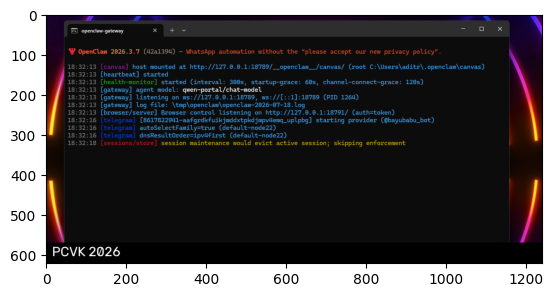

In [62]:
# Panggil fungsi dengan ekstensi .png yang sesuai
plt.imshow(tambah_label_dokumentasi('21.png'))


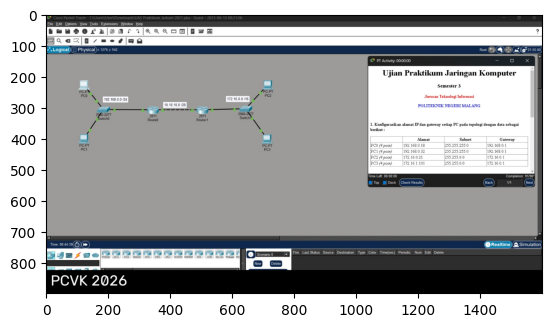

In [65]:
# Panggil fungsi dengan ekstensi .png yang sesuai
plt.imshow(tambah_label_dokumentasi('123.jpeg'))

In [66]:
def buat_thumbnail_square(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img_rgb.shape
    max_dim = max(h, w)

    # kanvas NumPy persegi warna putih
    canvas = np.full((max_dim, max_dim, 3), 255, dtype=np.uint8)

    # Hitung offset untuk menempatkan gambar tepat di tengah
    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2

    # Menempatkan gambar menggunakan slicing NumPy
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img_rgb

    # Teks nama toko
    font_scale = max_dim / 800.0
    thickness = max(1, int(font_scale * 3))
    cv2.putText(canvas, "Toko Aditya", (20, max_dim - 20),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (100, 100, 100), thickness)

    return canvas


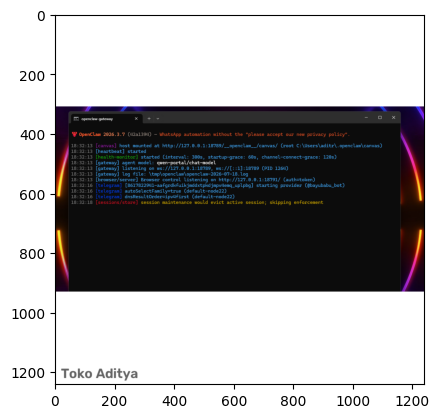

In [67]:
plt.imshow(buat_thumbnail_square('21.png'))

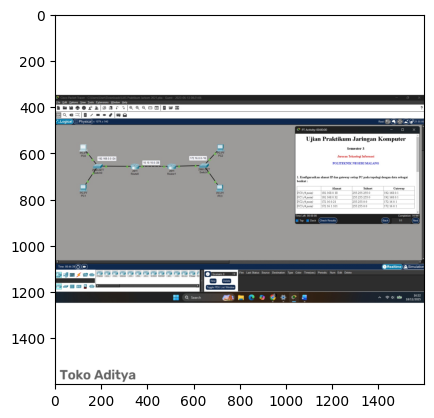

In [69]:
plt.imshow(buat_thumbnail_square('123.jpeg'))